# Diplomatura en IA - UP 
### Practico N°2 - Jun26
### Alumno: Gonzalez Marta Elizabeth 
### Notebook 02 - EDA -

In [1]:
# Importacion de Librerias

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

pd.set_option('display.max_columns', None)

print("Librerías cargadas")

Librerías cargadas


#### Variables y Carga del Dataset

In [2]:
# Ubicacion del dataset excel:

PATH = "../data/processed/01_dataset_analizado.csv"

In [3]:
# Lectura del archivo generado en Notebook 01

df = pd.read_csv(PATH)


In [4]:
# Dimensiones

print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

Cantidad de filas: 50000
Cantidad de columnas: 27


In [5]:
# Primeras observaciones:

df.head()

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,4.750000,3.041667,3.916667,8.958333,3.416667,3.041667,5.250000,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0
1,1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,4.958333,2.916667,5.416667,8.000000,4.791667,1.750000,5.291667,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0
2,2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,5.750000,3.583333,3.708333,10.083333,7.583333,2.291667,6.291667,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1
3,3,M,40,165,70,3.666667,0.045139,0.045139,0.041667,0.041667,4.166667,2.500000,4.000000,13.416667,10.583333,1.875000,9.416667,0.588194,0.041667,0.041667,0.791667,1.083333,0.750000,Y,0,Y,0
4,4,F,40,155,60,3.583333,0.041667,0.041667,0.041667,0.041667,5.000000,3.083333,3.333333,7.666667,3.083333,2.583333,4.458333,0.503472,0.041667,0.004167,0.666667,0.583333,0.916667,Y,0,N,0


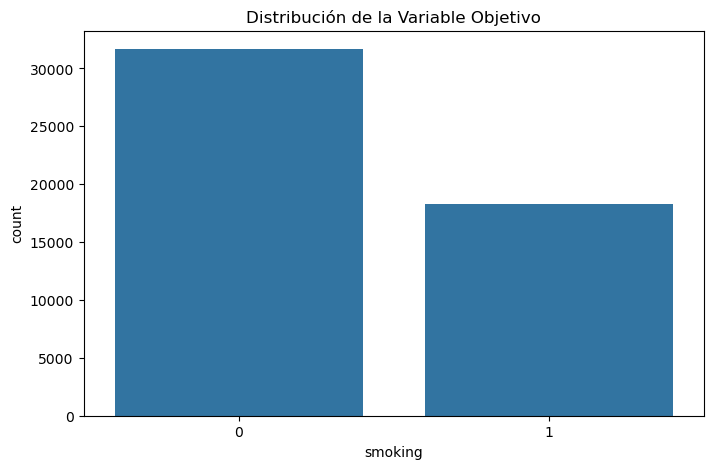

In [6]:
# Distribución de la variable objetivo

plt.figure(figsize=(8,5))

sns.countplot(
    x='smoking',
    data=df
)

plt.title('Distribución de la Variable Objetivo')
plt.show()

In [7]:
# Porcentajes

round(
    df['smoking'].value_counts(normalize=True)*100,
    2
)

smoking
0    63.34
1    36.66
Name: proportion, dtype: float64

In [8]:
# Distribución de variables numéricas

numericas = df.select_dtypes(
    include=['int64','float64']
).columns

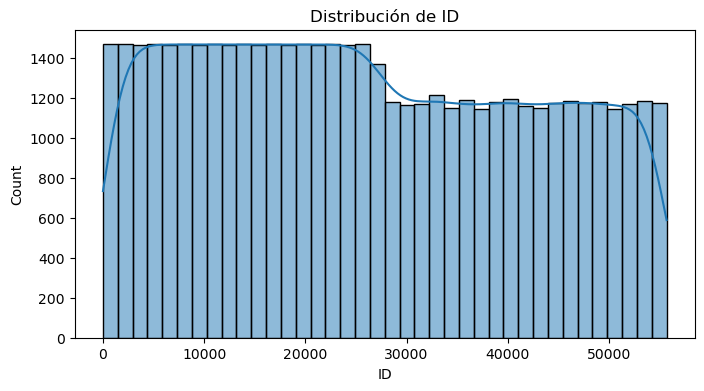

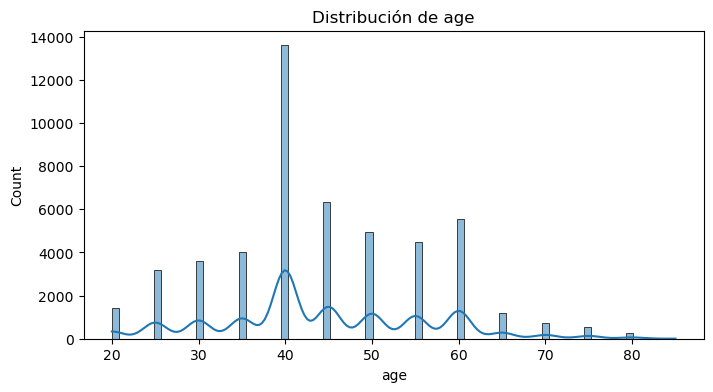

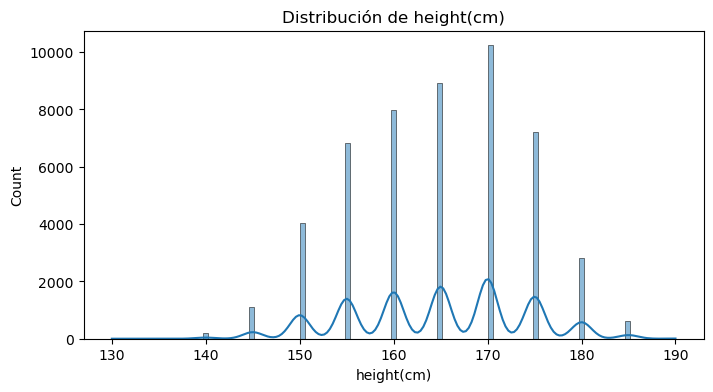

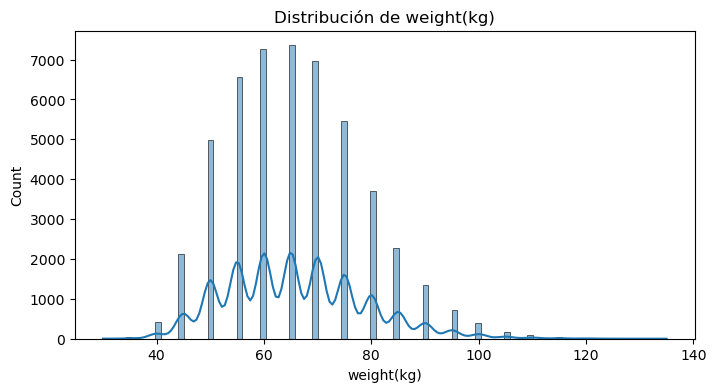

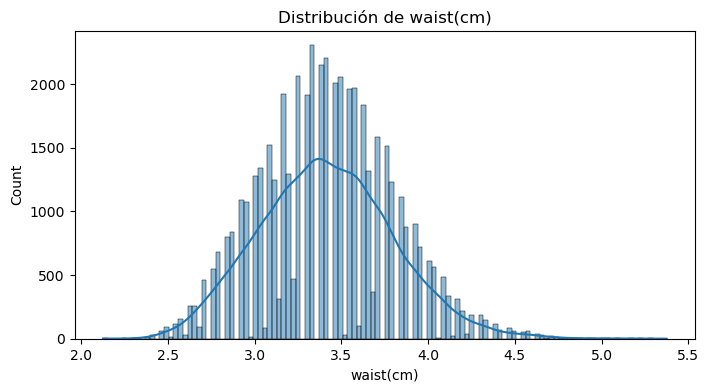

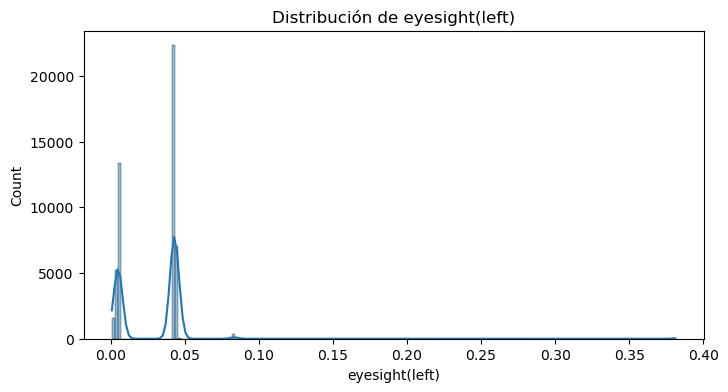

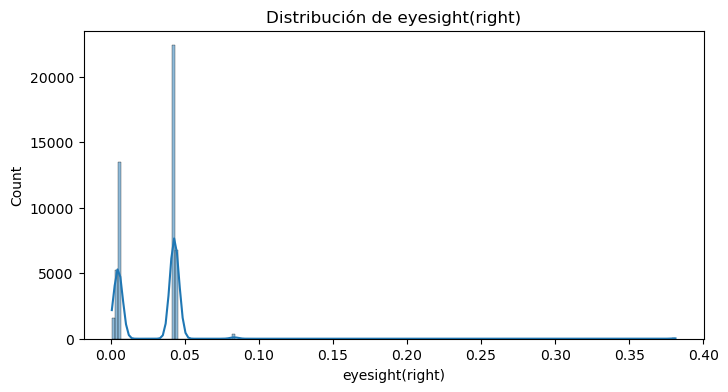

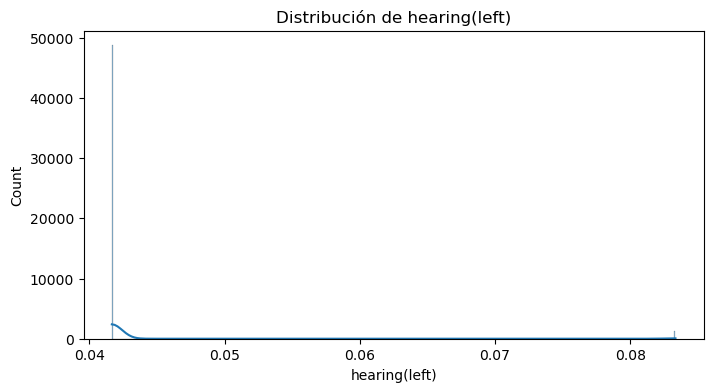

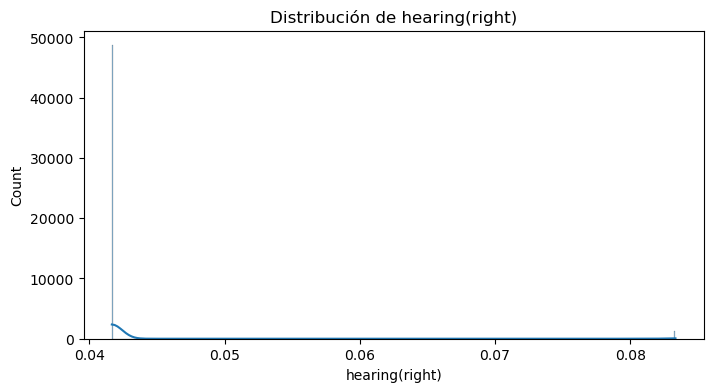

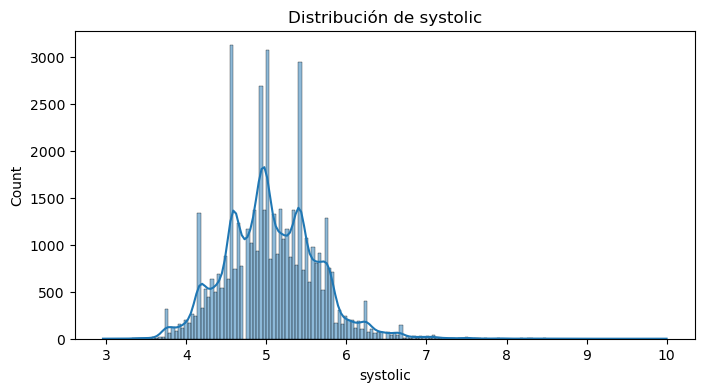

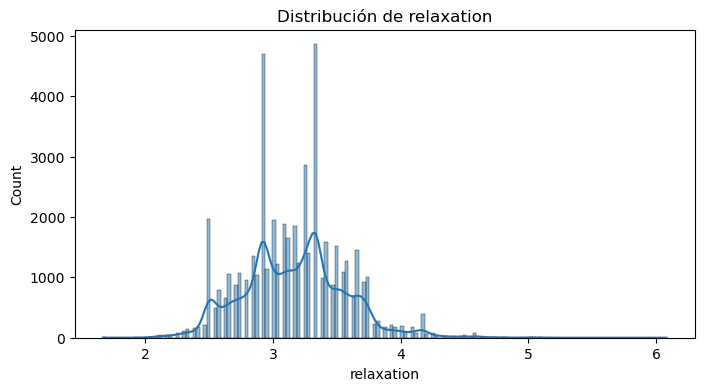

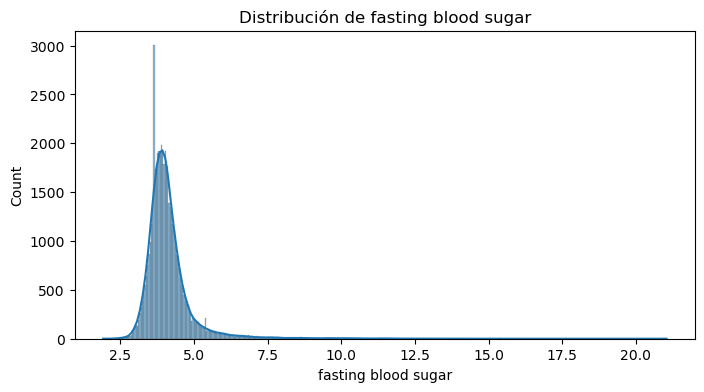

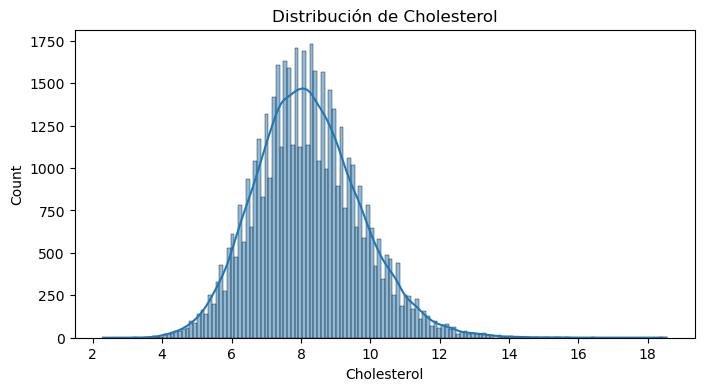

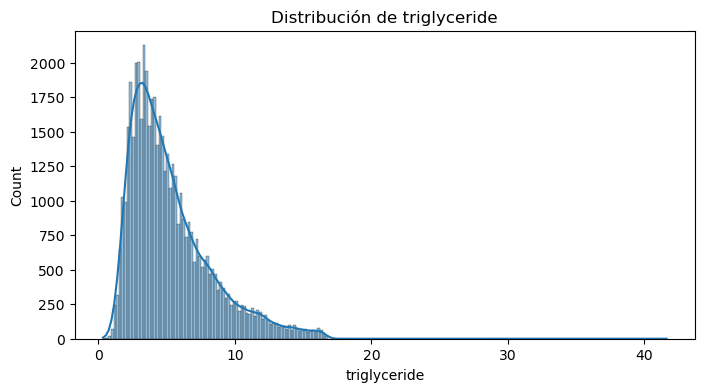

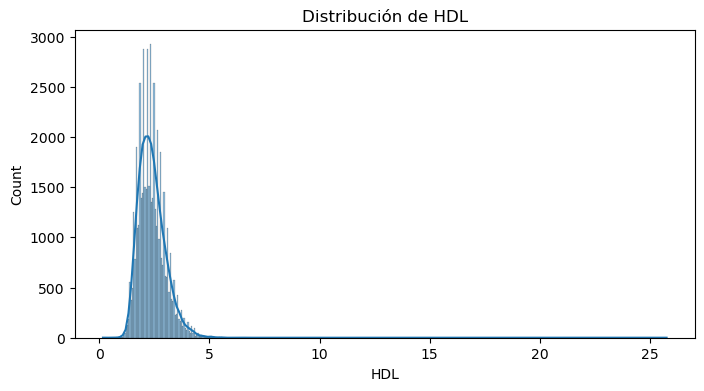

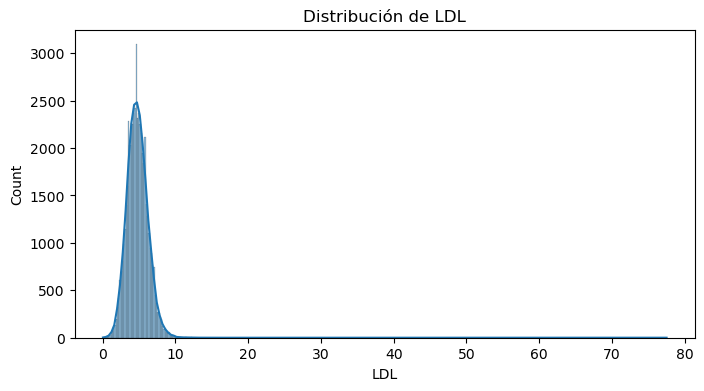

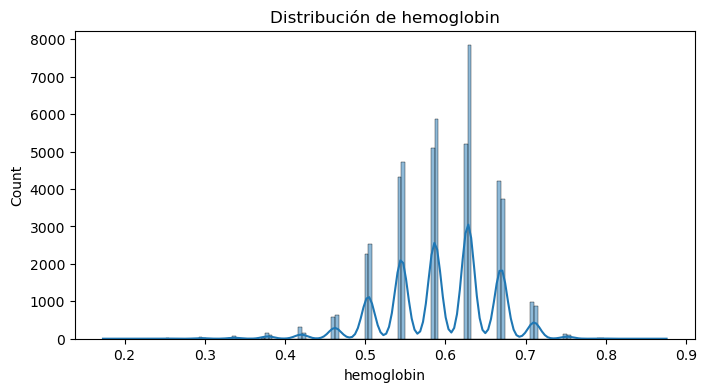

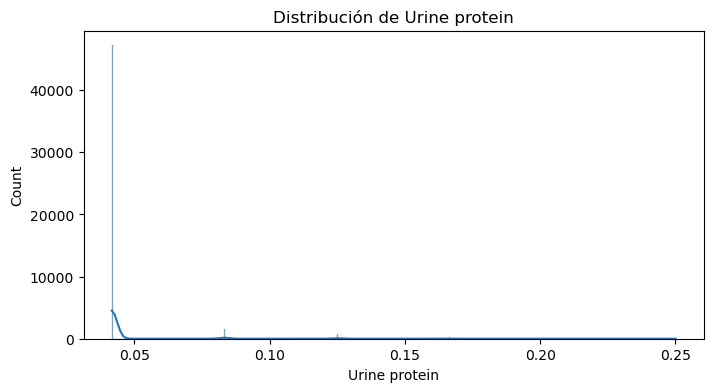

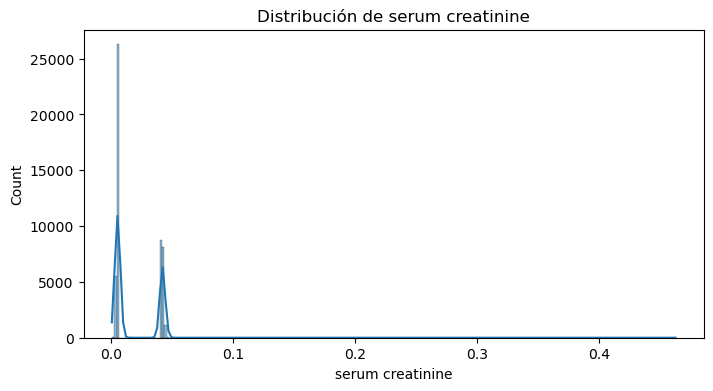

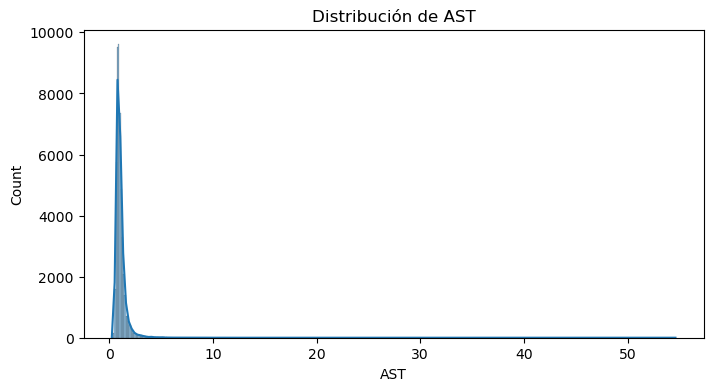

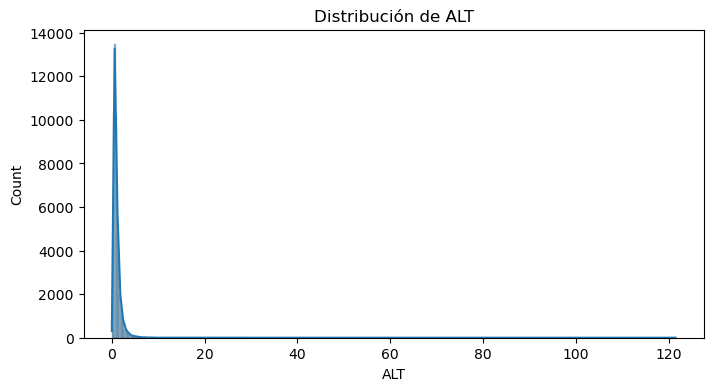

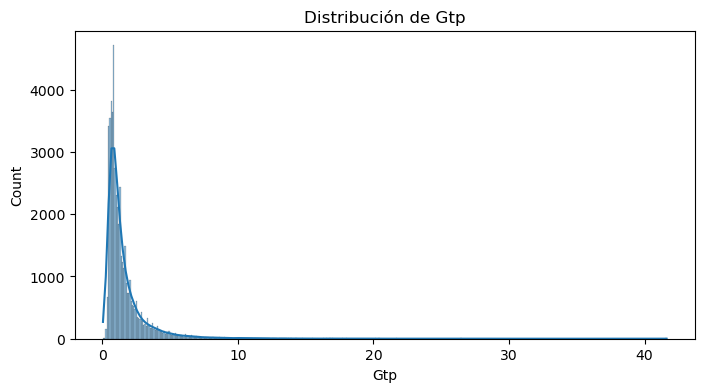

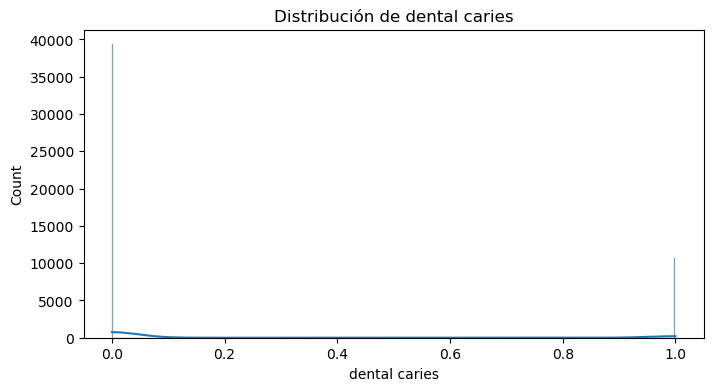

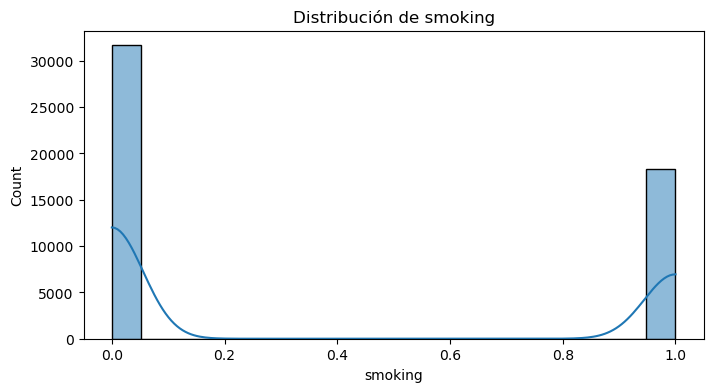

In [9]:
# Histogramas

for col in numericas:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Distribución de {col}')

    plt.show()

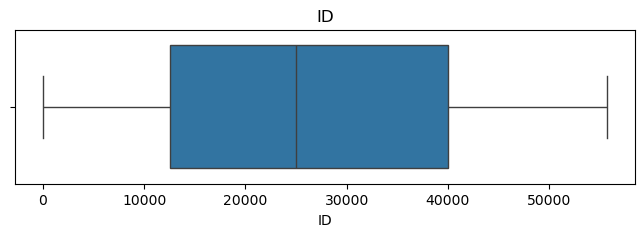

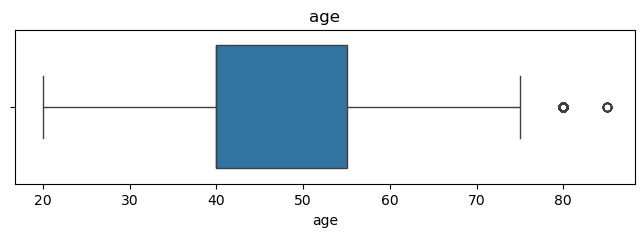

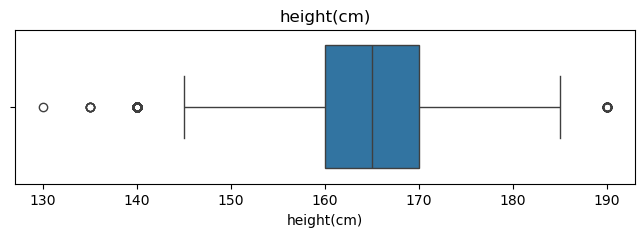

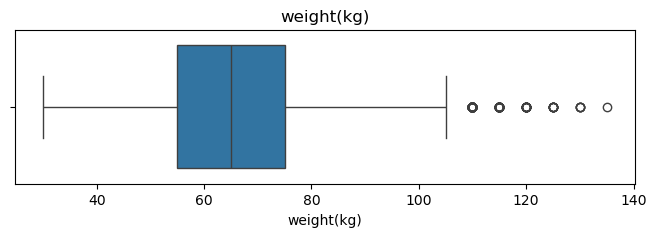

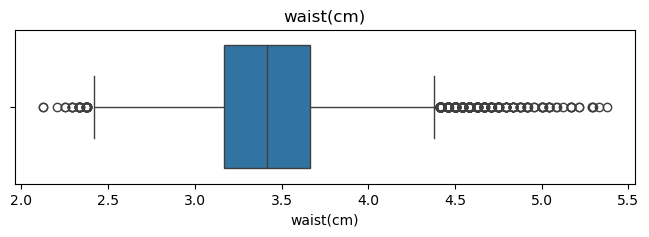

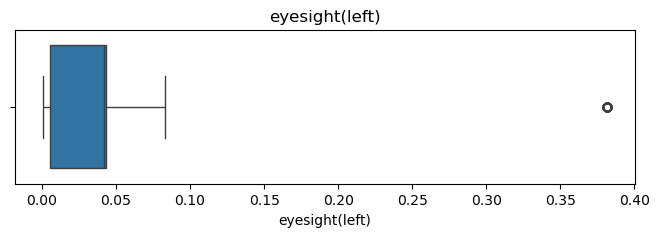

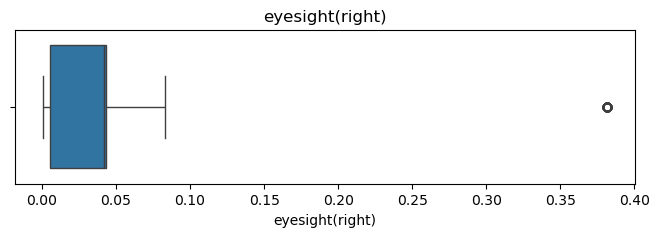

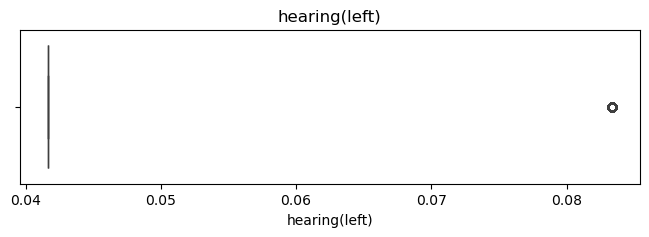

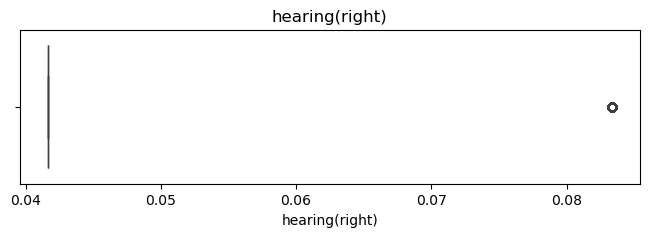

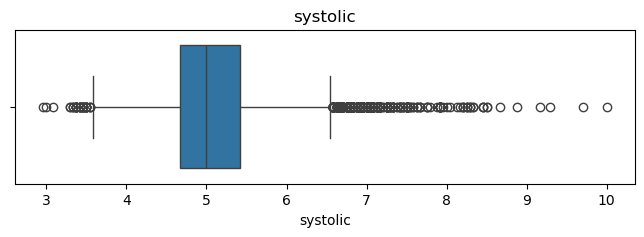

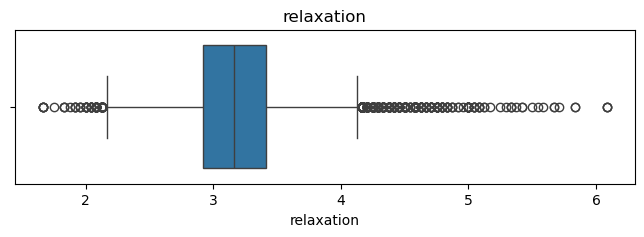

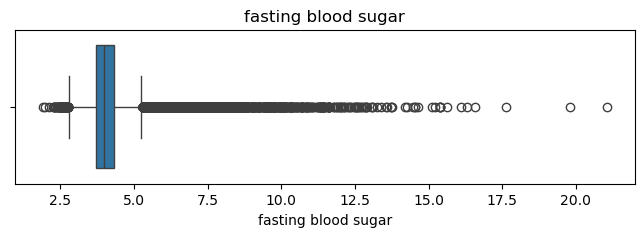

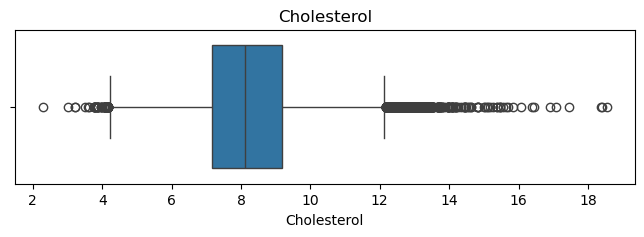

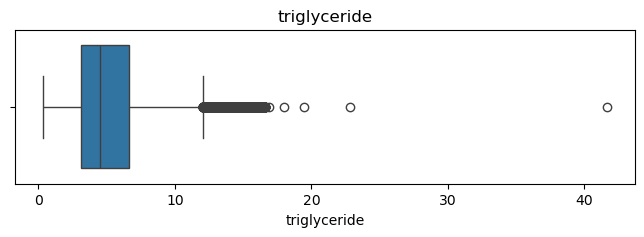

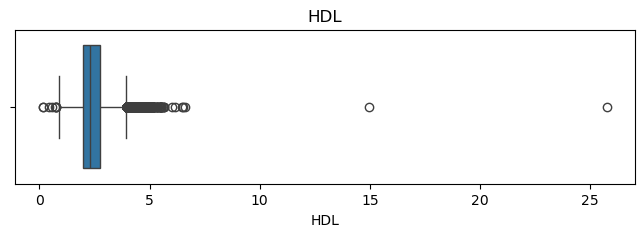

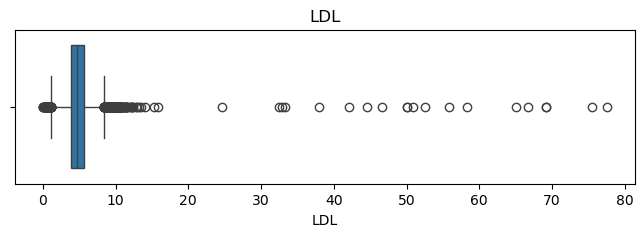

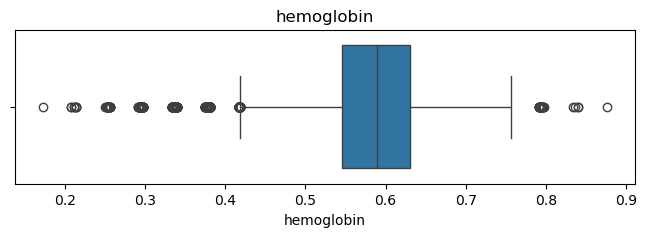

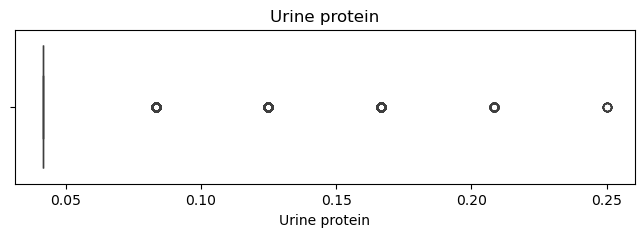

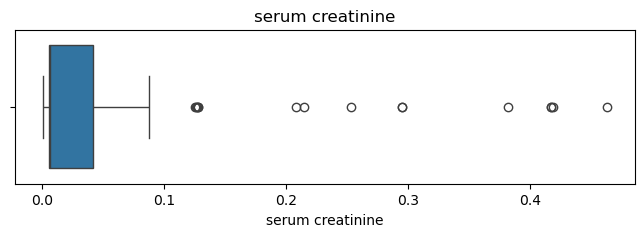

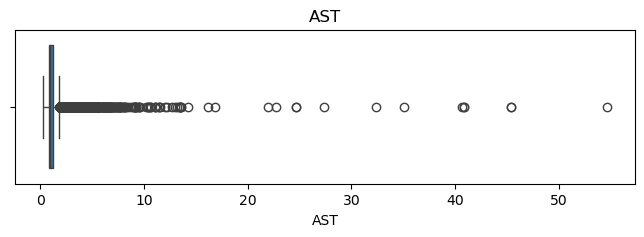

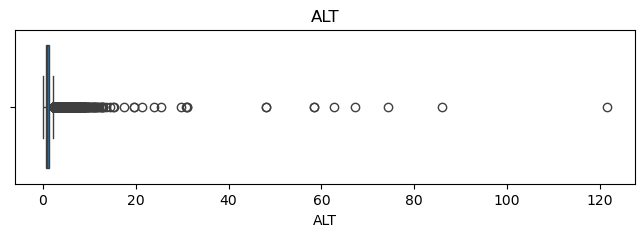

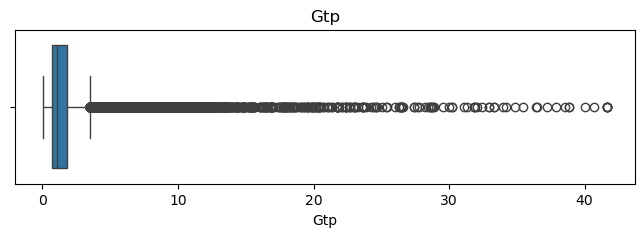

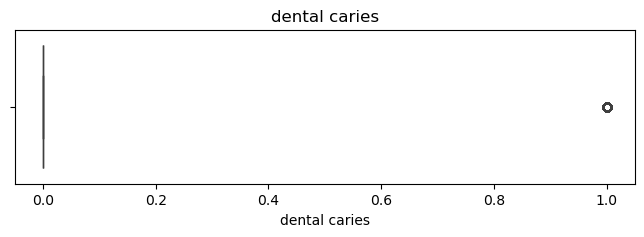

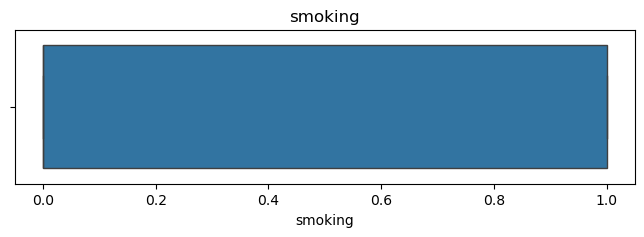

In [10]:
# Boxplots para detección visual de outliers

for col in numericas:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

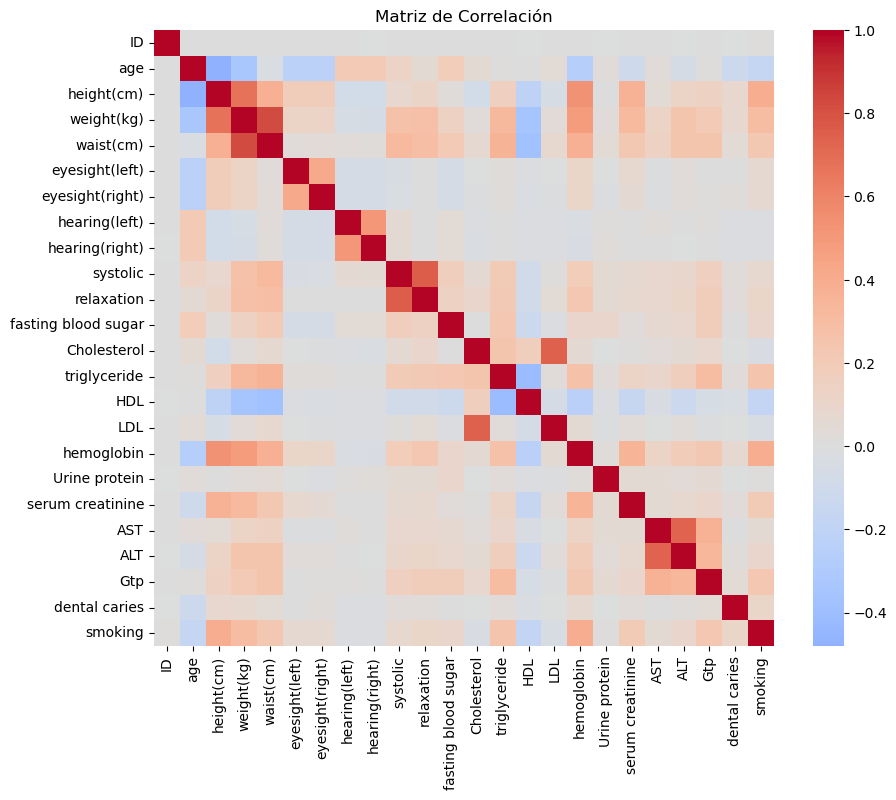

In [11]:
# Correlacion Global

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Matriz de Correlación")
plt.show()

In [12]:
# Correlacion con smoking

corr_smoking = (
    corr['smoking']
    .sort_values(ascending=False)
)

corr_smoking

smoking                1.000000
height(cm)             0.396284
hemoglobin             0.395972
weight(kg)             0.301405
triglyceride           0.251116
Gtp                    0.235980
waist(cm)              0.224623
serum creatinine       0.198660
relaxation             0.108155
dental caries          0.103757
fasting blood sugar    0.098124
ALT                    0.094137
systolic               0.073225
eyesight(right)        0.068783
eyesight(left)         0.066099
AST                    0.057348
Urine protein          0.015284
ID                     0.012211
hearing(right)        -0.017727
hearing(left)         -0.021871
Cholesterol           -0.030030
LDL                   -0.045706
age                   -0.163722
HDL                   -0.176993
Name: smoking, dtype: float64

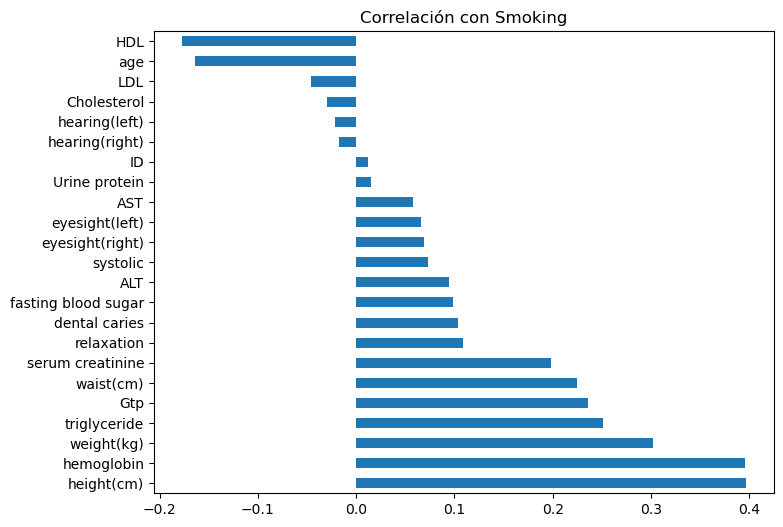

In [13]:
# Grafico de Correlacion smoking vs resto variables:

plt.figure(figsize=(8,6))

corr_smoking.drop('smoking').plot(
    kind='barh'
)

plt.title("Correlación con Smoking")

plt.show()

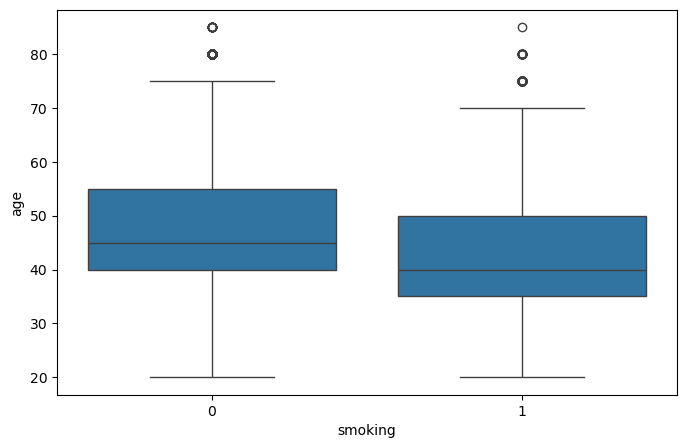

In [14]:
# Variables numéricas vs Smoking
# Edad

plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoking',
    y='age',
    data=df
)

plt.show()

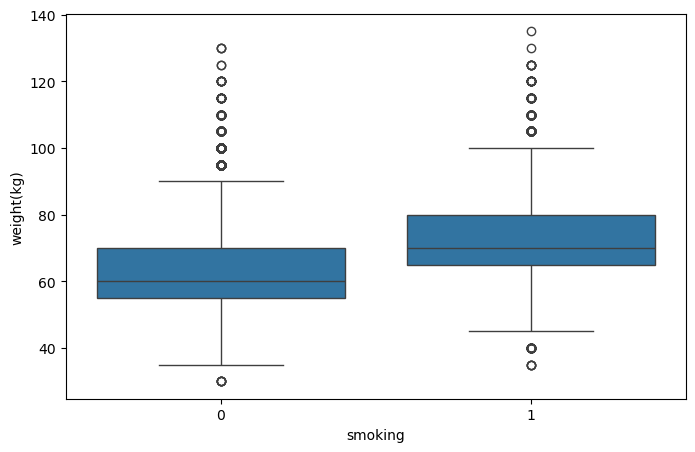

In [15]:
# Peso

plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoking',
    y='weight(kg)',
    data=df
)

plt.show()

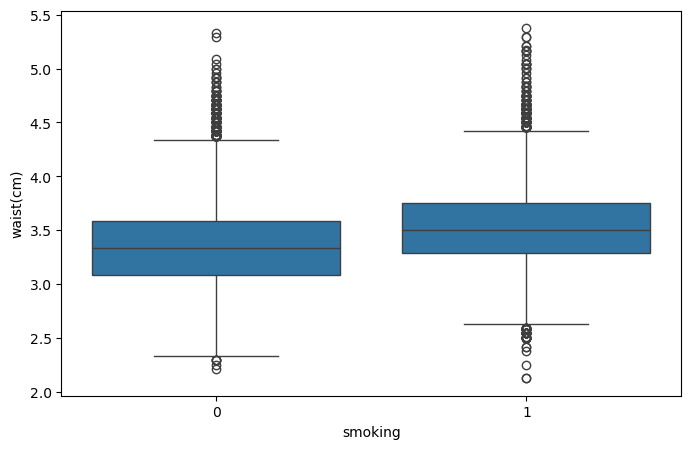

In [16]:
# Circunferencia de cintura

plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoking',
    y='waist(cm)',
    data=df
)

plt.show()

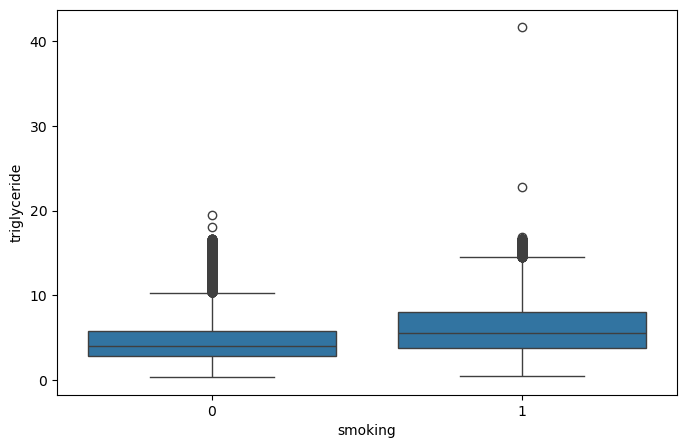

In [17]:
# Trigliceridos

plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoking',
    y='triglyceride',
    data=df
)

plt.show()

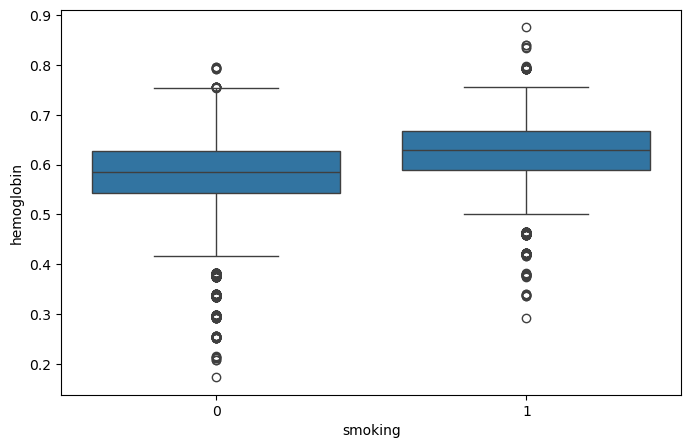

In [18]:
# Hemoglobina

plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoking',
    y='hemoglobin',
    data=df
)

plt.show()

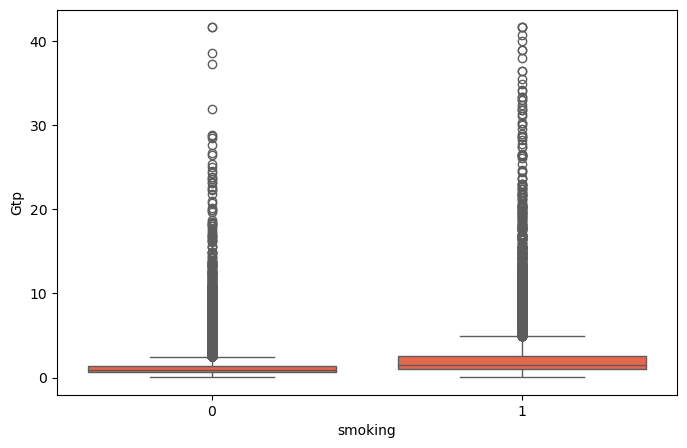

In [19]:
# Gtp

plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoking',
    y='Gtp',
    color= '#FF5733',
    data=df
)

plt.show()

In [20]:
# Variables categóricas vs Smoking
# Genero:

pd.crosstab(
    df['gender'],
    df['smoking'],
    normalize='index'
)*100

smoking,0,1
gender,,
F,95.723540,4.276460
M,44.783539,55.216461


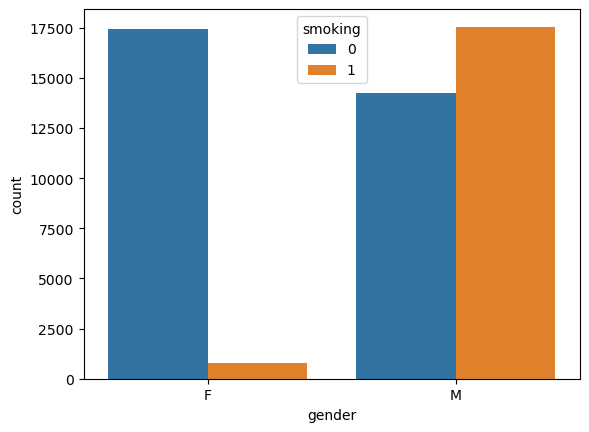

In [21]:
sns.countplot(
    x='gender',
    hue='smoking',
    data=df
)

plt.show()

In [22]:
# Tartar

pd.crosstab(
    df['tartar'],
    df['smoking'],
    normalize='index'
)*100

smoking,0,1
tartar,,
N,68.740714,31.259286
Y,59.026953,40.973047


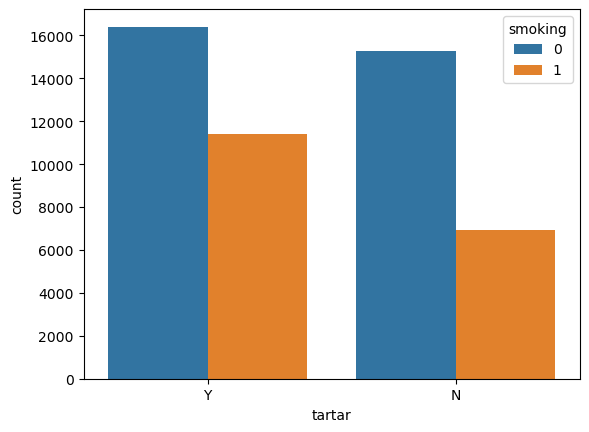

In [23]:
sns.countplot(
    x='tartar',
    hue='smoking',
    data=df
)

plt.show()

In [24]:
# Oral

pd.crosstab(
    df['oral'],
    df['smoking'],
    normalize='index'
)*100

smoking,0,1
oral,,
Y,63.342,36.658


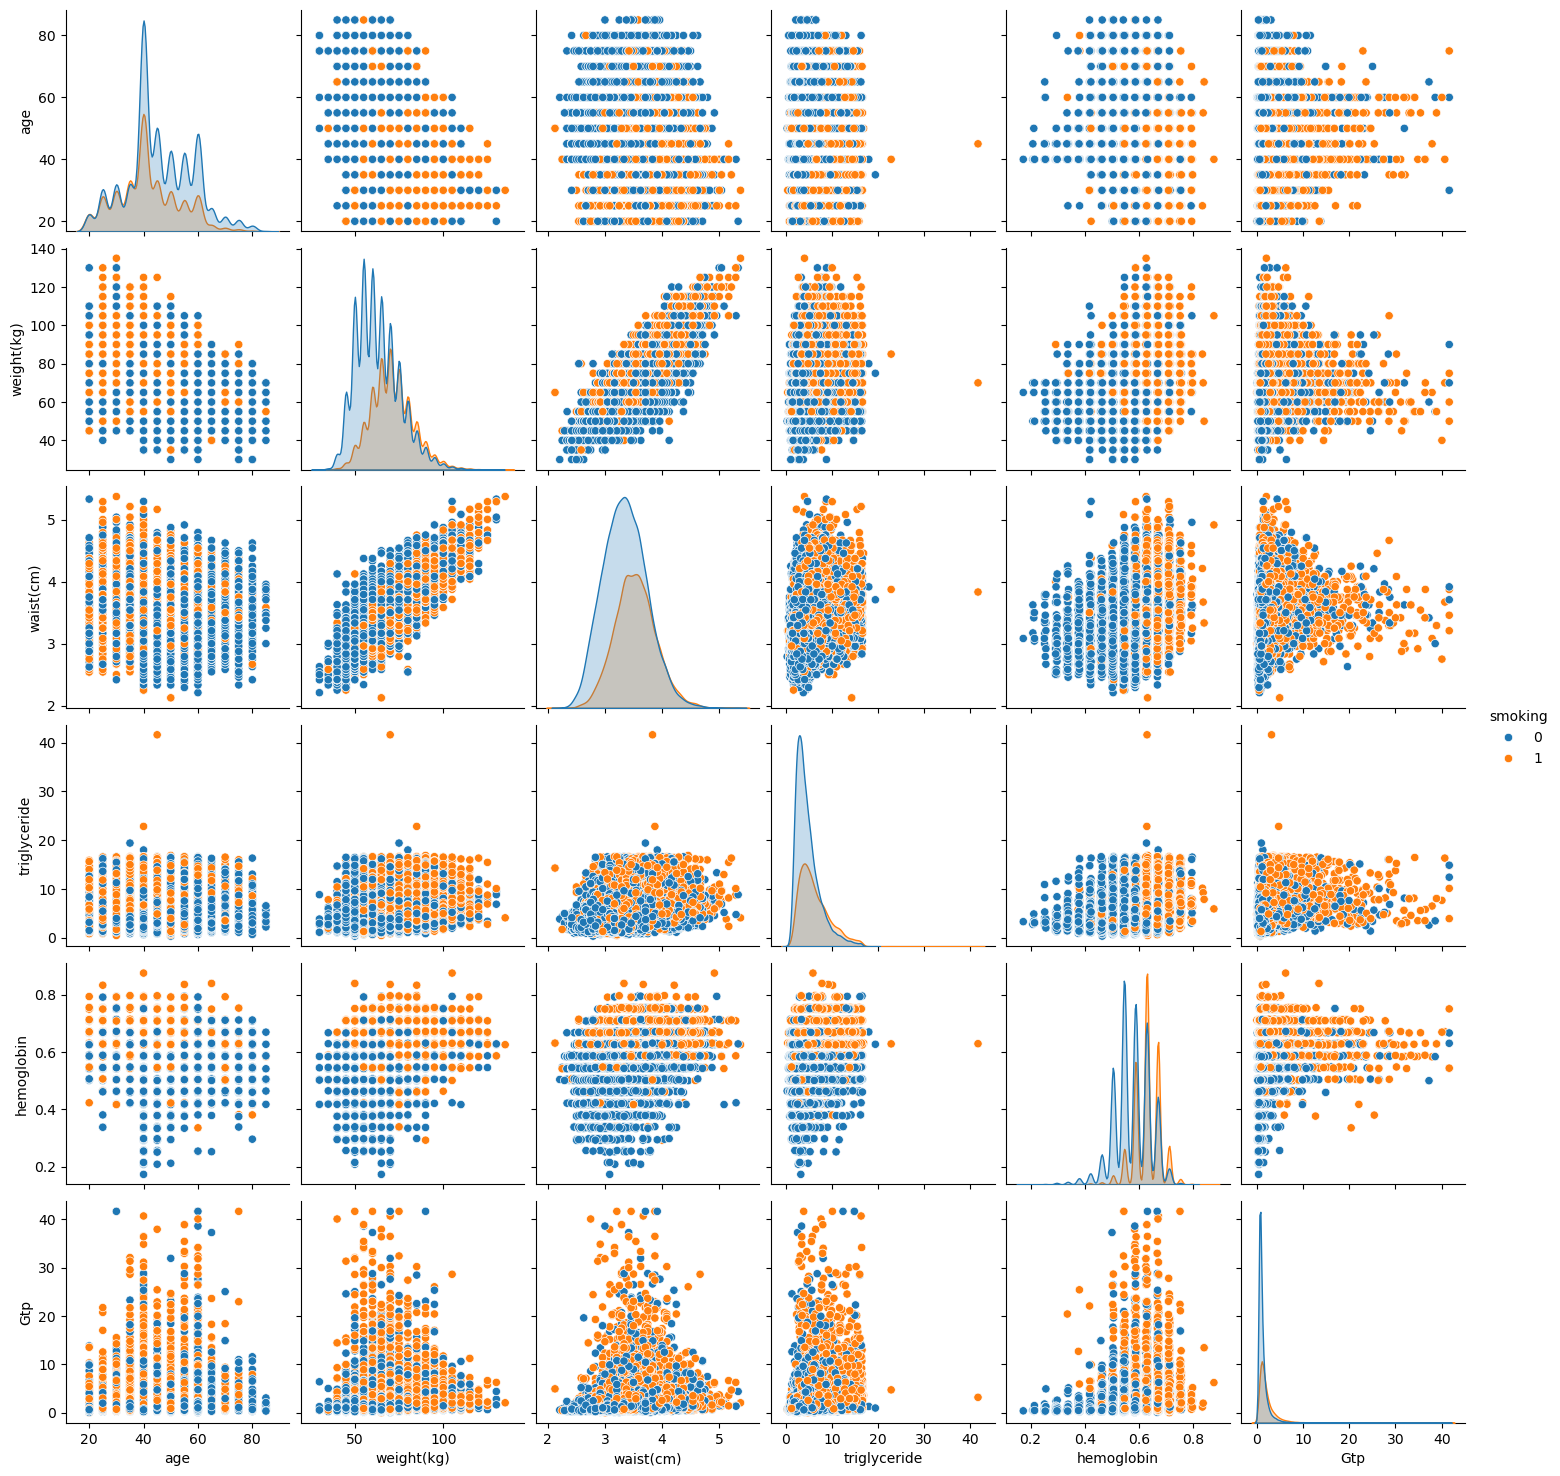

In [26]:
# Pairplots de variables relevantes

columnas = [
    'age',
    'weight(kg)',
    'waist(cm)',
    'triglyceride',
    'hemoglobin',
    'Gtp',
    'smoking'
]

sns.pairplot(
    df[columnas],
    hue='smoking'
)

plt.show()

In [27]:
from sklearn.feature_selection import mutual_info_classif

# Variables predictoras
X = df.drop('smoking', axis=1)

# Variable objetivo
y = df['smoking']

# Transformación temporal para Mutual Information
X_mi = pd.get_dummies(
    X,
    drop_first=True
)

# Cálculo de importancia
mi = mutual_info_classif(
    X_mi,
    y,
    random_state=42
)

In [29]:
mi_df = pd.DataFrame({
    'Variable': X_mi.columns,
    'Importancia': mi
})

mi_df = mi_df.sort_values(
    by='Importancia',
    ascending=False
)

mi_df.head(15)

,Variable,Importancia
23,gender_M,0.162169
16,hemoglobin,0.102674
2,height(cm),0.102480
21,Gtp,0.074168
3,weight(kg),0.056375
18,serum creatinine,0.044695
13,triglyceride,0.038877
4,waist(cm),0.029524
20,ALT,0.024723
14,HDL,0.018835


In [30]:
X = df.drop('smoking', axis=1)
y = df['smoking']

print(X.shape)
print(y.shape)

(50000, 26)
(50000,)


In [31]:
X_mi = pd.get_dummies(
    X,
    drop_first=True
)

print(X_mi.shape)

(50000, 25)


In [32]:
mi = mutual_info_classif(
    X_mi,
    y,
    random_state=42
)

print(len(mi))

25


In [33]:
mi_df = pd.DataFrame({
    'Variable': X_mi.columns,
    'Importancia': mi
})

mi_df.sort_values(
    'Importancia',
    ascending=False
).head(15)

,Variable,Importancia
23,gender_M,0.162169
16,hemoglobin,0.102674
2,height(cm),0.102480
21,Gtp,0.074168
3,weight(kg),0.056375
18,serum creatinine,0.044695
13,triglyceride,0.038877
4,waist(cm),0.029524
20,ALT,0.024723
14,HDL,0.018835


In [54]:
mi_df.head(15)

,Variable,Importancia
0,ID,0.002630
1,age,0.016077
2,height(cm),0.102480
3,weight(kg),0.056375
4,waist(cm),0.029524
5,eyesight(left),0.007032
6,eyesight(right),0.005601
7,hearing(left),0.005179
8,hearing(right),0.004423
9,systolic,0.005758


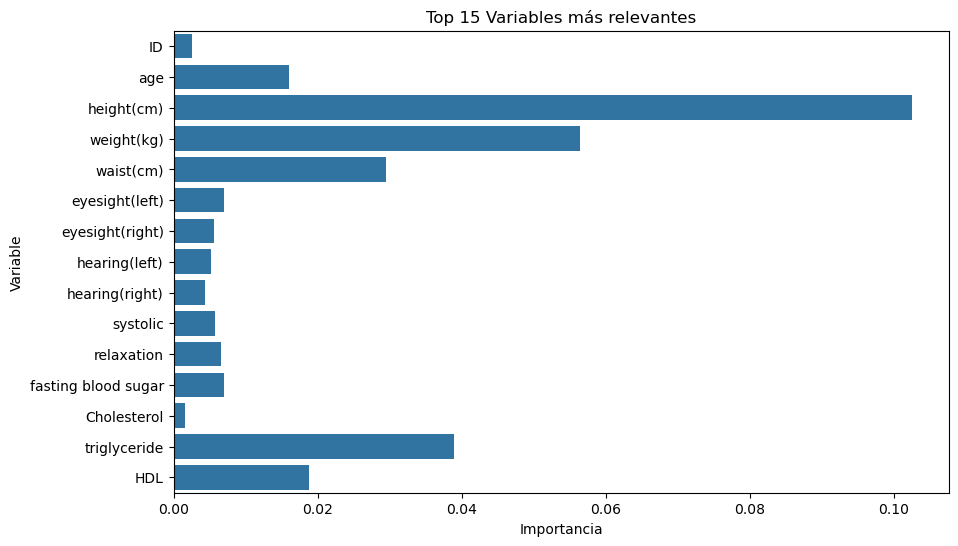

In [35]:
# Grafico

plt.figure(figsize=(10,6))

sns.barplot(
    data=mi_df.head(15),
    x='Importancia',
    y='Variable'
)

plt.title("Top 15 Variables más relevantes")

plt.show()

In [36]:
mi_df.head(20)

,Variable,Importancia
0,ID,0.002630
1,age,0.016077
2,height(cm),0.102480
3,weight(kg),0.056375
4,waist(cm),0.029524
5,eyesight(left),0.007032
6,eyesight(right),0.005601
7,hearing(left),0.005179
8,hearing(right),0.004423
9,systolic,0.005758


In [41]:
corr_smoking

smoking                1.000000
height(cm)             0.396284
hemoglobin             0.395972
weight(kg)             0.301405
triglyceride           0.251116
Gtp                    0.235980
waist(cm)              0.224623
serum creatinine       0.198660
relaxation             0.108155
dental caries          0.103757
fasting blood sugar    0.098124
ALT                    0.094137
systolic               0.073225
eyesight(right)        0.068783
eyesight(left)         0.066099
AST                    0.057348
Urine protein          0.015284
ID                     0.012211
hearing(right)        -0.017727
hearing(left)         -0.021871
Cholesterol           -0.030030
LDL                   -0.045706
age                   -0.163722
HDL                   -0.176993
Name: smoking, dtype: float64

In [42]:
mi_df.sort_values(
    by='Importancia',
    ascending=False
).head(20)

,Variable,Importancia
23,gender_M,0.162169
16,hemoglobin,0.102674
2,height(cm),0.102480
21,Gtp,0.074168
3,weight(kg),0.056375
18,serum creatinine,0.044695
13,triglyceride,0.038877
4,waist(cm),0.029524
20,ALT,0.024723
14,HDL,0.018835


In [44]:
corr_smoking = (
    corr['smoking']
    .sort_values(ascending=False)
)

corr_smoking

smoking                1.000000
height(cm)             0.396284
hemoglobin             0.395972
weight(kg)             0.301405
triglyceride           0.251116
Gtp                    0.235980
waist(cm)              0.224623
serum creatinine       0.198660
relaxation             0.108155
dental caries          0.103757
fasting blood sugar    0.098124
ALT                    0.094137
systolic               0.073225
eyesight(right)        0.068783
eyesight(left)         0.066099
AST                    0.057348
Urine protein          0.015284
ID                     0.012211
hearing(right)        -0.017727
hearing(left)         -0.021871
Cholesterol           -0.030030
LDL                   -0.045706
age                   -0.163722
HDL                   -0.176993
Name: smoking, dtype: float64

In [45]:
[col for col in X_mi.columns if 'gender' in col]

['gender_M']

In [46]:
# Exportación para Notebook 03

df.to_csv(
    "../data/processed/02_dataset_eda.csv",
    index=False
)

print("Archivo exportado correctamente")

Archivo exportado correctamente
